# Variant regulatory consequence analysis

This notebook introduces new dataset `Epiraction`, which contains the regulatory consequences for variants.


## Data loading

The data requires two datasets:

- `Epiraction` dataset, which contains the regulatory consequences for variants.
- `LeadVariantEffect` dataset, which contains the lead variants and their effects. - use qualified replicated maf filtered dataset.


In [7]:
from __future__ import annotations

from enum import Enum

import pandas as pd
import plotnine as p9
from gentropy.common.session import Session
from pyspark.sql import Column, Window
from pyspark.sql import functions as f

from manuscript_methods import OpenTargetsTheme, group_statistics
from manuscript_methods.consequence import ConsequenceCategory
from manuscript_methods.datasets import LeadVariantEffect
from gentropy.assets.variant_consequences import VariantConsequence


In [2]:
session = Session(extended_spark_conf={"spark.driver.memory": "120G"})


26/01/12 12:57:52 WARN Utils: Your hostname, mindos resolves to a loopback address: 127.0.1.1; using 192.168.0.100 instead (on interface eno1)
26/01/12 12:57:52 WARN Utils: Set SPARK_LOCAL_IP if you need to bind to another address
Setting default log level to "WARN".
To adjust logging level use sc.setLogLevel(newLevel). For SparkR, use setLogLevel(newLevel).
26/01/12 12:57:53 WARN NativeCodeLoader: Unable to load native-hadoop library for your platform... using builtin-java classes where applicable
26/01/12 12:57:53 WARN Utils: Service 'SparkUI' could not bind on port 4040. Attempting port 4041.


In [4]:
dataset_path = "../../../data/EPIraction"

# lead_variant_maf = "../../data/qualified_lead_variant_effect_maf_filtered"
lead_variant_maf = "../../../data/intermediate_files/qualified_lead_variant_effect"

so_terms_path = "../../data/so_terms.tsv"
pd.set_option("display.max_colwidth", None)


In [5]:
session.spark


In [8]:
epirack = session.spark.read.parquet(dataset_path)
lve = LeadVariantEffect.from_parquet(session=session, path=lead_variant_maf)
so_terms_dict = VariantConsequence.map_sequence_ontology()
so_terms = pd.DataFrame([(d, i) for d, i in so_terms_dict.items()], columns=["term", "featureId"])
so_terms.head()


def map_so_terms(so_term_col: Column, so_terms: pd.DataFrame) -> Column:
    """Map Sequence Ontology (SO) terms to their ids without joining."""
    expr = f.when(f.lit(False), None)
    so_terms = so_terms[["featureId", "term"]]
    for v in so_terms.iterrows():
        so_term = v[1][1]
        so_id = v[1][0]
        expr = expr.when(so_term_col == f.lit(so_id), f.lit(so_term))

    return expr


In [ ]:
lve.df.show(1)


+---------------+--------------------+--------------------+------------+------+--------------------+---------------------+--------------------+-----------------+----------+--------------------+-----------------+--------------------+--------------------+--------------------+--------------------+--------------------+----------------------+------------------------+
|      variantId|             variant|        studyLocusId|     studyId|geneId|        originalBeta|originalStandardError|     locusStatistics|finemappingMethod|isTransQtl|       variantEffect|majorLdPopulation|majorLdPopulationMaf| majorLdPopulationAf|   variantStatistics|     studyStatistics|  rescaledStatistics|leadVariantConsequence|traitFromSourceMappedIds|
+---------------+--------------------+--------------------+------------+------+--------------------+---------------------+--------------------+-----------------+----------+--------------------+-----------------+--------------------+--------------------+-----------------

## Consequence classification

We classify the consequences into 4 categories:

- intergenic (upstream, downstream, and intergenic regions)
- regulatory (LOW or MODIFIER impact, bound to regulatory regions)
- intragenic (LOW or MODIFIER impact, rest)
- protein_altering (HIGH and MODERATE impact)

We need to merge the so_terms dataset, so the featureId contains the `SO_XXX` format rather then `SO:XXX` format.


In [ ]:
# Change SO terms to the `SO_XXX` format
so_terms["featureId"] = so_terms["featureId"].str.replace("SO:", "SO_")


## Merging of LVE x Epiraction datasets

In order to add the regulatory consequences from the Epiraction we need to merge the `LeadVariantEffect` dataset with the Epiraction dataset. The Epiraction dataset contains the regulatory consequences for interval regions.

The Epiraction interval region is defined as
| chromosome | start | end | intervalType |
|------------|---------|---------|----------------|
| chr1 | 128717 | 129517 | promoter |
| chr1 | 138675 | 139325 | enhancer |
| chr1 | 96475 | 96925 | enhancer |
| chr1 | 103950 | 104600 | enhancer |

Where the `intervalType` can be `promoter` or `enhancer`

<div class="alert alert-block alert-info"> 
<b> Epiraction interval offset </b>
<br>
    Epiraction intervals are 0-based (based on bed intervals), while the `LeadVariantEffect` dataset is 1-based. This means that we need to add 1 to the start and end positions of the Epiraction intervals when merging with the 
    `LeadVariantEffect` dataset.
<br>
<br>
<img src="plots/0_vs_1_based.png" width="500"/>
</div>

The join to the `LeadVariantEffect` dataset is done using the positions to the lead variant.


### Extract the relevant information from both datasets


In [ ]:
def map_so_terms(so_term_col: Column, so_terms: pd.DataFrame) -> Column:
    """Map Sequence Ontology (SO) terms to their ids without joining."""
    expr = f.when(f.lit(False), None)
    so_terms = so_terms[["featureId", "term"]]
    for v in so_terms.iterrows():
        so_term = v[1][1]
        so_id = v[1][0]
        expr = expr.when(f.lit(so_id) == so_term_col, f.lit(so_term))

    return expr


In [ ]:
# Prefilter lead variants
lve_dataset = lve.df.select(
    f.col("variantId"),
    f.col("studyLocusId"),
    f.col("studyId"),
    f.col("geneId"),
    f.col("variant.chromosome").alias("chromosome"),
    f.col("variant.start").alias("start"),
    f.col("variant.end").alias("end"),
    f.col("leadVariantConsequence").getField("mostSevereConsequence").getField("type").alias("variantPositionEffect"),
    f.col("leadVariantConsequence")
    .getField("mostSevereConsequence")
    .getField("transcriptConsequence")
    .getField("consequenceScore")
    .alias("consequenceScore"),
    f.col("leadVariantConsequence")
    .getField("mostSevereConsequence")
    .getField("transcriptConsequence")
    .getField("variantFunctionalConsequenceIds")
    .alias("consequenceIds"),
    f.col("studyStatistics").getField("studyType").alias("studyType"),
    f.col("majorLdPopulationMaf").getField("value").alias("MAF"),
    f.col("rescaledStatistics").getField("absEstimatedBeta").alias("estimatedBeta"),
    f.col("rescaledStatistics").getField("estimatedSE").alias("estimatedSE"),
    f.col("studyStatistics").getField("traitClass").alias("traitClass"),
).withColumn("consequenceOntologyTerms", f.transform(f.col("consequenceIds"), lambda x: map_so_terms(x, so_terms)))
# Filter based on score distribution - see 05.0 notebook
epirack_dataset = (
    epirack.filter(f.col("score") > 0.05)
    .dropDuplicates(["chromosome", "start", "end", "intervalType"])
    .select(
        f.regexp_replace(f.col("chromosome"), "chr", "").alias("chromosome"),
        (f.col("start") + 1).alias("start"),
        (f.col("end") + 1).alias("end"),
        "intervalType",
    )
)


AnalysisException: [FIELD_NOT_FOUND] No such struct field `estimatedBeta` in `directionOfEffect`, `absZScore`, `varG`, `prevalence`, `estimatedSE`, `absEstimatedBeta`, `minorAlleleEstimatedBeta`.

### Save the datasets as tables partitioned by chromosome and sorted by position


In [ ]:
lve_dataset.show(1, truncate=False)


+---------------+--------------------------------+------------+------+----------+--------+--------+---------------------+----------------+--------------+----------------+-------------------+--------------------+--------------------+------------+------------------------+
|variantId      |studyLocusId                    |studyId     |geneId|chromosome|start   |end     |variantPositionEffect|consequenceScore|consequenceIds|studyType       |MAF                |estimatedBeta       |estimatedSE         |traitClass  |consequenceOntologyTerms|
+---------------+--------------------------------+------------+------+----------+--------+--------+---------------------+----------------+--------------+----------------+-------------------+--------------------+--------------------+------------+------------------------+
|13_79013706_A_C|6dd41c42747e73659b4963b52a362c42|GCST90475159|NULL  |13        |79013706|79013706|in-gene-effect       |0.0             |[SO_0001631]  |gwas-measurement|0.400656403614635

In [ ]:
epirack_dataset.show(1, truncate=False)


+----------+---------+---------+------------+
|chromosome|start    |end      |intervalType|
+----------+---------+---------+------------+
|1         |1305301.0|1305876.0|enhancer    |
+----------+---------+---------+------------+
only showing top 1 row



In [ ]:
# epirack_dataset.write.mode("overwrite").bucketBy(50, "chromosome").sortBy("start").saveAsTable("epirack_intervals")


In [ ]:
# lve_dataset.write.mode("overwrite").bucketBy(50, "chromosome").sortBy("start").saveAsTable("lve_lead_variants")


In [ ]:
epirack_dataset.write.mode("overwrite").parquet("../../data/epirack_intervals")
lve_dataset.write.mode("overwrite").parquet("../../data/lve_lead_variants")


### Perform the join between the LeadVariantEffect and Epiraction datasets

The join is left on lead_variant, so we keep all the lead variants and add the Epiraction information where available.

The Epiraction intervals are added when the lead variant is within the Epiraction interval.


In [ ]:
# lve_dataset_table = session.spark.table("lve_lead_variants")
# epirack_dataset_table = session.spark.table("epirack_intervals")


In [ ]:
lve_dataset_table = session.spark.read.parquet("../../data/lve_lead_variants")
epirack_dataset_table = session.spark.read.parquet("../../data/epirack_intervals")


In [ ]:
lve_dataset_table.count()


459516

In [ ]:
lve_dataset_table.show(1)


+--------------+--------------------+--------------------+---------------+----------+--------+--------+---------------------+----------------+--------------+---------+------------------+-------------------+-------------------+------------+------------------------+
|     variantId|        studyLocusId|             studyId|         geneId|chromosome|   start|     end|variantPositionEffect|consequenceScore|consequenceIds|studyType|               MAF|      estimatedBeta|        estimatedSE|  traitClass|consequenceOntologyTerms|
+--------------+--------------------+--------------------+---------------+----------+--------+--------+---------------------+----------------+--------------+---------+------------------+-------------------+-------------------+------------+------------------------+
|7_95324583_G_A|73baebd7c5ab7167c...|gtex_exon_liver_e...|ENSG00000005421|         7|95324583|95324583|       in-gene-effect|             0.0|  [SO_0001631]|     eqtl|0.4763503745564463|-0.9198640080621929

In [ ]:
# lve_dataset_table = lve_dataset_table.withColumn("id", f.monotonically_increasing_id())


In [ ]:
lve_dataset_table.dropDuplicates(["studyLocusId"]).count()


459516

In [ ]:
si = session.spark.read.parquet("../../data/study")
si.count()


1966178

In [ ]:
lve_dataset_table = lve_dataset_table.drop("geneId").join(
    si.select("studyId", "diseaseIds", "geneId", "biosampleId"), on="studyId", how="inner"
)
lve_dataset_table.count()


459516

In [ ]:
lve_dataset_table.show(1)


+--------------------+---------------+--------------------+----------+--------+--------+---------------------+----------------+--------------------+------------+-------------------+-------------------+-------------------+----------+------------------------+-------------+------+-----------+
|             studyId|      variantId|        studyLocusId|chromosome|   start|     end|variantPositionEffect|consequenceScore|      consequenceIds|   studyType|                MAF|      estimatedBeta|        estimatedSE|traitClass|consequenceOntologyTerms|   diseaseIds|geneId|biosampleId|
+--------------------+---------------+--------------------+----------+--------+--------+---------------------+----------------+--------------------+------------+-------------------+-------------------+-------------------+----------+------------------------+-------------+------+-----------+
|FINNGEN_R12_AD_LO...|10_11676714_A_G|4dabcba79fb33f6da...|        10|11676714|11676714|       in-gene-effect|             0.1|

In [ ]:
nc_dataset = lve_dataset_table.join(
    epirack_dataset_table,
    on=(
        (lve_dataset_table.chromosome == epirack_dataset_table.chromosome)
        & (lve_dataset_table.start >= epirack_dataset_table.start)
        & (lve_dataset_table.end < epirack_dataset_table.end)
    ),
    how="left",
).select(
    lve_dataset_table.variantId,
    lve_dataset_table.chromosome,
    lve_dataset_table.start,
    lve_dataset_table.end,
    lve_dataset_table.variantPositionEffect,
    lve_dataset_table.consequenceScore,
    lve_dataset_table.consequenceOntologyTerms,
    lve_dataset_table.studyType,
    lve_dataset_table.MAF,
    lve_dataset_table.estimatedBeta,
    lve_dataset_table.estimatedSE,
    lve_dataset_table.traitClass,
    lve_dataset_table.studyLocusId,
    lve_dataset_table.geneId,
    lve_dataset_table.diseaseIds,
    lve_dataset_table.biosampleId,
    epirack_dataset_table.intervalType,
)


In [ ]:
nc_dataset.count()


461297

In [ ]:
nc_dataset.dropDuplicates(["studyLocusId"]).count()


459516

In [ ]:
nc_dataset.filter(f.col("variantId") == "19_8364439_G_A").show(5)


+--------------+----------+-------+-------+---------------------+----------------+------------------------+----------------+--------------------+--------------------+--------------------+------------+--------------------+------+--------------------+-----------+------------+
|     variantId|chromosome|  start|    end|variantPositionEffect|consequenceScore|consequenceOntologyTerms|       studyType|                 MAF|       estimatedBeta|         estimatedSE|  traitClass|        studyLocusId|geneId|          diseaseIds|biosampleId|intervalType|
+--------------+----------+-------+-------+---------------------+----------------+------------------------+----------------+--------------------+--------------------+--------------------+------------+--------------------+------+--------------------+-----------+------------+
|19_8364439_G_A|        19|8364439|8364439|       in-gene-effect|            0.66|      [missense_variant]|gwas-measurement|0.019657962390444334|-0.13690683181821142|0.0150149

In [ ]:
nc_dataset.filter(f.col("variantId") == "19_8364439_G_A").groupBy("intervalType").count().show()


+------------+-----+
|intervalType|count|
+------------+-----+
|    promoter|  368|
+------------+-----+



In [ ]:
nc_dataset.groupBy("intervalType").count().show()


+------------+------+
|intervalType| count|
+------------+------+
|        NULL|337192|
|    enhancer| 74434|
|    promoter| 49671|
+------------+------+



In [ ]:
nc_dataset.filter(f.col("consequenceScore") >= 0.66).groupBy("intervalType").count().show()


+------------+-----+
|intervalType|count|
+------------+-----+
|        NULL|23867|
|    enhancer| 4511|
|    promoter| 3570|
+------------+-----+



In [ ]:
# nc_dataset=nc_dataset.dropDuplicates(["studyLocusId"])
# nc_dataset.show(1, truncate=False)


In [ ]:
nc_dataset.count()


461297

### Save the dataset after joining


In [ ]:
nc_dataset.write.mode("overwrite").parquet("../../data/nc_dataset")


In [ ]:
nc_dataset = session.spark.read.parquet("../../data/nc_dataset")


In [ ]:
nc_dataset.groupBy("studyType").count().show()


+----------------+------+
|       studyType| count|
+----------------+------+
|gwas-measurement| 91296|
|        cis-pqtl|  1498|
|    gwas-disease| 12706|
|            eqtl|355797|
+----------------+------+



In [ ]:
nc_dataset.count()


461297

In [ ]:
nc_dataset = nc_dataset.withColumn(
    "consequence",
    f.explode(
        f.filter(
            f.array_distinct(
                f.array_sort(
                    f.array_append(
                        f.transform(
                            f.array_distinct(f.col("consequenceOntologyTerms")),
                            lambda x: ConsequenceCategory.classify_so_terms(x),
                        ),
                        f.col("intervalType"),
                    )
                )
            ),
            lambda x: x.isNotNull(),
        )
    ),
).cache()
nc_dataset.count()


588948

In [ ]:
nc_dataset.show(1)


+---------------+----------+--------+--------+---------------------+----------------+------------------------+------------+-------------------+-------------------+--------------------+----------+--------------------+------+-------------+-----------+------------+----------------+
|      variantId|chromosome|   start|     end|variantPositionEffect|consequenceScore|consequenceOntologyTerms|   studyType|                MAF|      estimatedBeta|         estimatedSE|traitClass|        studyLocusId|geneId|   diseaseIds|biosampleId|intervalType|     consequence|
+---------------+----------+--------+--------+---------------------+----------------+------------------------+------------+-------------------+-------------------+--------------------+----------+--------------------+------+-------------+-----------+------------+----------------+
|11_62243391_C_T|        11|62243391|62243391|       in-gene-effect|            0.66|      [missense_variant]|gwas-disease|0.40427061839554806|0.176768653557417

In [ ]:
nc_dataset.filter(f.col("variantId") == "19_8364439_G_A").show(5, truncate=False)


+--------------+----------+-------+-------+---------------------+----------------+------------------------+----------------+--------------------+--------------------+--------------------+------------+--------------------------------+------+-------------+-----------+------------+----------------+
|variantId     |chromosome|start  |end    |variantPositionEffect|consequenceScore|consequenceOntologyTerms|studyType       |MAF                 |estimatedBeta       |estimatedSE         |traitClass  |studyLocusId                    |geneId|diseaseIds   |biosampleId|intervalType|consequence     |
+--------------+----------+-------+-------+---------------------+----------------+------------------------+----------------+--------------------+--------------------+--------------------+------------+--------------------------------+------+-------------+-----------+------------+----------------+
|19_8364439_G_A|19        |8364439|8364439|in-gene-effect       |0.66            |[missense_variant]      |gw

In [ ]:
nc_dataset = nc_dataset.withColumn(
    "consequence_priority",
    f.when(f.col("consequence") == "protein_altering", 5)
    .when(f.col("consequence") == "promoter", 4)
    .when(f.col("consequence") == "enhancer", 3)
    .when(f.col("consequence") == "intragenic", 2)
    .when(f.col("consequence") == "intergenic", 1)
    .otherwise(0),  # For any unexpected values
)


In [ ]:
nc_dataset.groupBy("consequence_priority").count().show()


+--------------------+------+
|consequence_priority| count|
+--------------------+------+
|                   1| 95468|
|                   3| 74434|
|                   5| 30773|
|                   4| 49671|
|                   2|338602|
+--------------------+------+



In [ ]:
nc_dataset.groupBy("consequence").count().show()


+----------------+------+
|     consequence| count|
+----------------+------+
|      intragenic|338602|
|        enhancer| 74434|
|protein_altering| 30773|
|      intergenic| 95468|
|        promoter| 49671|
+----------------+------+



In [ ]:
# Select only one row per studyLocusId with highest consequence_priority
from pyspark.sql.window import Window

# Create window specification partitioned by studyLocusId and ordered by consequence_priority descending
window_spec = Window.partitionBy("studyLocusId").orderBy(f.desc("consequence_priority"))

# Add row number and filter to keep only the first row (highest priority) for each studyLocusId
nc_dataset_filtered = (
    nc_dataset.withColumn("row_num", f.row_number().over(window_spec)).filter(f.col("row_num") == 1).drop("row_num")
).cache()

nc_dataset_filtered.count()


459516

In [ ]:
nc_dataset.filter(f.col("variantId") == "19_8364439_G_A").groupBy("consequence").count().show()


+----------------+-----+
|     consequence|count|
+----------------+-----+
|protein_altering|  368|
|        promoter|  368|
+----------------+-----+



In [ ]:
nc_dataset_filtered.filter(f.col("variantId") == "19_8364439_G_A").groupBy("consequence").count().show()


+----------------+-----+
|     consequence|count|
+----------------+-----+
|protein_altering|  368|
+----------------+-----+



In [ ]:
nc_dataset_filtered.write.mode("overwrite").parquet("../../data/nc_dataset_filtered")


## Unify the consequence terms with Epiraction interval types

Before unification, we need to ensure that all the filtering is applied. We need two datasets:

1. **Mean estimated effect size in consequence categories** (gwas_dataset). The analysis is done on

   - the common variants (MAF >= 0.01)
   - with absolute value of estimated effect size <= 3
   - GWAS replicated credible sets (studyType == "gwas")
   - traitClass == "binary"

2. **Consequence categories fraction of all consequences across study types** (merged_dataset). The analysis is done on

   - the common variants (MAF >= 0.01)
   - with absolute value of estimated effect size <= 3
   - replicated credible sets (studyType == "gwas", "eqtl", "cis-pqtl")

After applying the specific filtering we need to unify the consequence terms with the Epiraction interval types. The unification is done by

- maping the consequence terms to consequence categories
- adding the Epiraction interval types to the consequence categories
- deduplicating the consequence terms
- removing the null entries (due to the left-join)
- exploding the unified non-duplicated list of terms.

At the end we remove the duplicates based on the variantId, consequence, and studyType.


In [ ]:
nc_dataset = session.spark.read.parquet("../../data/nc_dataset_filtered")
nc_dataset.count()


459516

In [ ]:
nc_dataset.show(1)


+--------------+----------+-------+-------+---------------------+----------------+------------------------+----------------+--------------------+-------------------+--------------------+------------+--------------------+------+-------------+-----------+------------+----------------+--------------------+
|     variantId|chromosome|  start|    end|variantPositionEffect|consequenceScore|consequenceOntologyTerms|       studyType|                 MAF|      estimatedBeta|         estimatedSE|  traitClass|        studyLocusId|geneId|   diseaseIds|biosampleId|intervalType|     consequence|consequence_priority|
+--------------+----------+-------+-------+---------------------+----------------+------------------------+----------------+--------------------+-------------------+--------------------+------------+--------------------+------+-------------+-----------+------------+----------------+--------------------+
|19_8364439_G_A|        19|8364439|8364439|       in-gene-effect|            0.66|   

In [ ]:
# Extract only GWAS
gwas_dataset = (
    nc_dataset.filter(f.col("studyType").isin("gwas-disease")).select(
        "variantId",
        "intervalType",
        "estimatedBeta",
        "estimatedSE",
        "studyType",
        "consequenceOntologyTerms",
        "MAF",
        "studyLocusId",
        "geneId",
        "biosampleId",
        "diseaseIds",
        "consequence",
    )
).cache()
gwas_dataset.count()


25/11/02 23:04:18 WARN CacheManager: Asked to cache already cached data.


12694

In [ ]:
gwas_dataset.count()


12694

In [ ]:
# Extract only GWAS
gwas_measurement = (
    nc_dataset.filter(f.col("studyType").isin("gwas-measurement")).select(
        "variantId",
        "intervalType",
        "estimatedBeta",
        "estimatedSE",
        "studyType",
        "consequenceOntologyTerms",
        "MAF",
        "studyLocusId",
        "geneId",
        "biosampleId",
        "diseaseIds",
        "consequence",
    )
).cache()
gwas_measurement.count()


91147

In [ ]:
# Keep only the row with highest estimatedBeta for each variantId, diseaseIds, intervalType combination
# from pyspark.sql.window import Window

# window_spec = Window.partitionBy("variantId", "diseaseIds", "intervalType").orderBy(f.desc(f.abs("estimatedBeta")))
# gwas_measurement = gwas_measurement.withColumn("row_num", f.row_number().over(window_spec)).filter(f.col("row_num") == 1).drop("row_num")
# gwas_measurement.count()


In [ ]:
# Extract merged dataset
molQTLs_dataset = (
    nc_dataset.filter(f.col("studyType").isin("cis-pqtl", "eqtl")).select(
        "variantId",
        "intervalType",
        "estimatedBeta",
        "estimatedSE",
        "studyType",
        "consequenceOntologyTerms",
        "MAF",
        "studyLocusId",
        "geneId",
        "biosampleId",
        "diseaseIds",
        "consequence",
    )
).cache()
molQTLs_dataset.count()


355675

In [ ]:
merged_dataset = molQTLs_dataset.union(gwas_dataset).union(gwas_measurement).cache()
merged_dataset.count()


459516

In [ ]:
# Combine gwas_measurement and gwas_dataset (equivalent to rbind in R)
combined_gwas_dataset = gwas_measurement.union(gwas_dataset)
combined_gwas_dataset.count()


103841

## Mean estimated effect size in consequence categories

The analysis is made to see the difference between the mean estimated effect size in different consequence categories within the GWAS replicated binary credible sets.


In [ ]:
group_statistics(gwas_dataset, [f.col("consequence")]).show()


+----------------+-----+-----+------------------+
|     consequence|count|    %|        percentage|
+----------------+-----+-----+------------------+
|      intragenic| 6097|48.03| 48.03056562155349|
|      intergenic| 2180|17.17| 17.17346778005357|
|protein_altering| 2083|16.41|16.409327241216324|
|        enhancer| 2014|15.87|15.865763352765086|
|        promoter|  320| 2.52| 2.520876004411533|
+----------------+-----+-----+------------------+



In [ ]:
group_statistics(combined_gwas_dataset, [f.col("consequence")]).show()


+----------------+-----+-----+------------------+
|     consequence|count|    %|        percentage|
+----------------+-----+-----+------------------+
|      intragenic|49725|47.89|  47.8857098833794|
|      intergenic|18989|18.29|18.286611261447792|
|protein_altering|16633|16.02|16.017757918355947|
|        enhancer|15096|14.54|14.537610385108001|
|        promoter| 3398| 3.27|3.2723105517088626|
+----------------+-----+-----+------------------+



In [ ]:
group_statistics(gwas_measurement, [f.col("consequence")]).show()


+----------------+-----+-----+------------------+
|     consequence|count|    %|        percentage|
+----------------+-----+-----+------------------+
|      intragenic|43628|47.87| 47.86553589256914|
|      intergenic|16809|18.44|18.441638232744907|
|protein_altering|14550|15.96|15.963224242158272|
|        enhancer|13082|14.35|14.352639143361824|
|        promoter| 3078| 3.38| 3.376962489165853|
+----------------+-----+-----+------------------+



### Aggregate the estimated effect sizes

The aggregation is done by the consequence and studyType


In [ ]:
beta = "\u03b2"
hat = "\u0302"
plus_minus = "\u00b1"


data_diseases = (
    gwas_dataset.groupBy("consequence", "studyType")
    .agg(
        f.mean(f.abs("estimatedBeta")).alias("meanAbsEstimatedBeta"),
        f.stddev(f.abs("estimatedBeta")).alias("stddevAbsEstimatedBeta"),
        (f.lit(1.96) * f.stddev(f.abs("estimatedBeta")) / f.sqrt(f.count(f.abs("estimatedBeta")))).alias(
            "intervalAbsEstimatedBeta"
        ),
        f.count(f.col("variantId")).alias("variantCount"),
    )
    .withColumn(
        "label",
        f.concat_ws(
            " / ",
            "consequence",
            f.concat_ws("=", f.lit("N"), "variantCount"),
            f.concat_ws(
                plus_minus,
                f.concat_ws("=", f.lit(beta + hat), f.round("meanAbsEstimatedBeta", 3)),
                f.round("intervalAbsEstimatedBeta", 3),
            ),
        ),
    )
    .toPandas()
)
data_diseases


,consequence,studyType,meanAbsEstimatedBeta,stddevAbsEstimatedBeta,intervalAbsEstimatedBeta,variantCount,label
0,protein_altering,gwas-disease,0.316452,0.378044,0.016235,2083,protein_altering / N=2083 / β̂=0.316±0.016
1,intergenic,gwas-disease,0.204160,0.267710,0.011238,2180,intergenic / N=2180 / β̂=0.204±0.011
2,enhancer,gwas-disease,0.166060,0.210047,0.009174,2014,enhancer / N=2014 / β̂=0.166±0.009
3,promoter,gwas-disease,0.151842,0.181538,0.019891,320,promoter / N=320 / β̂=0.152±0.02
4,intragenic,gwas-disease,0.186521,0.239477,0.006011,6097,intragenic / N=6097 / β̂=0.187±0.006


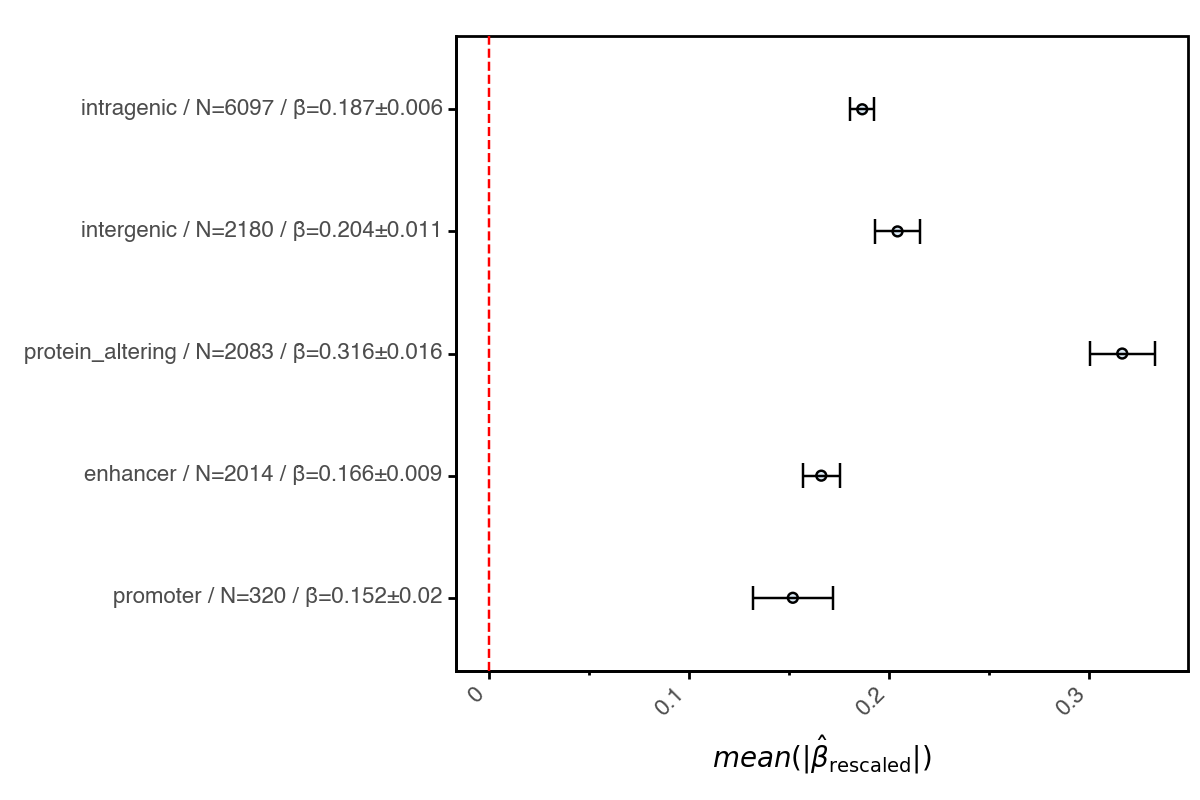

<Figure Size: (600 x 400)>

In [ ]:
plot = (
    p9.ggplot(data_diseases)
    + p9.geom_point(p9.aes(x="reorder(label, variantCount)", y="meanAbsEstimatedBeta"), fill="#DBEAF6")
    + OpenTargetsTheme.theme
    + p9.theme(figure_size=(10, 6))
    # move the y-axis label to the bottom
    + p9.theme(axis_text_y=p9.element_text(rotation=0))
    + p9.geom_errorbar(
        p9.aes(
            x="label",
            ymin="meanAbsEstimatedBeta - intervalAbsEstimatedBeta",
            ymax="meanAbsEstimatedBeta + intervalAbsEstimatedBeta",
        ),
        width=0.2,
        position=p9.position_dodge(width=0.9),
    )
    + p9.labs(x="", y=r"$mean(|\hat{\beta}_{\mathrm{rescaled}}|)$")
    + p9.theme(legend_position="left", figure_size=(6, 4))  # Remove the legend
    # Remove the color scale from legend
    + p9.geom_hline(p9.aes(yintercept=0), linetype="dashed", color="red", size=0.5)
    + p9.coord_flip()
)
plot


In [ ]:
beta = "\u03b2"
hat = "\u0302"
plus_minus = "\u00b1"


data_measurement = (
    gwas_measurement.groupBy("consequence", "studyType")
    .agg(
        f.mean(f.abs("estimatedBeta")).alias("meanAbsEstimatedBeta"),
        f.stddev(f.abs("estimatedBeta")).alias("stddevAbsEstimatedBeta"),
        (f.lit(1.96) * f.stddev(f.abs("estimatedBeta")) / f.sqrt(f.count(f.abs("estimatedBeta")))).alias(
            "intervalAbsEstimatedBeta"
        ),
        f.count(f.col("variantId")).alias("variantCount"),
    )
    .withColumn(
        "label",
        f.concat_ws(
            " / ",
            "consequence",
            f.concat_ws("=", f.lit("N"), "variantCount"),
            f.concat_ws(
                plus_minus,
                f.concat_ws("=", f.lit(beta + hat), f.round("meanAbsEstimatedBeta", 3)),
                f.round("intervalAbsEstimatedBeta", 3),
            ),
        ),
    )
    .toPandas()
)
data_measurement


,consequence,studyType,meanAbsEstimatedBeta,stddevAbsEstimatedBeta,intervalAbsEstimatedBeta,variantCount,label
0,enhancer,gwas-measurement,0.073183,0.129945,0.002227,13082,enhancer / N=13082 / β̂=0.073±0.002
1,intergenic,gwas-measurement,0.080123,0.146654,0.002217,16809,intergenic / N=16809 / β̂=0.08±0.002
2,intragenic,gwas-measurement,0.085954,0.156812,0.001471,43628,intragenic / N=43628 / β̂=0.086±0.001
3,promoter,gwas-measurement,0.100853,0.228479,0.008072,3078,promoter / N=3078 / β̂=0.101±0.008
4,protein_altering,gwas-measurement,0.160632,0.245919,0.003996,14550,protein_altering / N=14550 / β̂=0.161±0.004


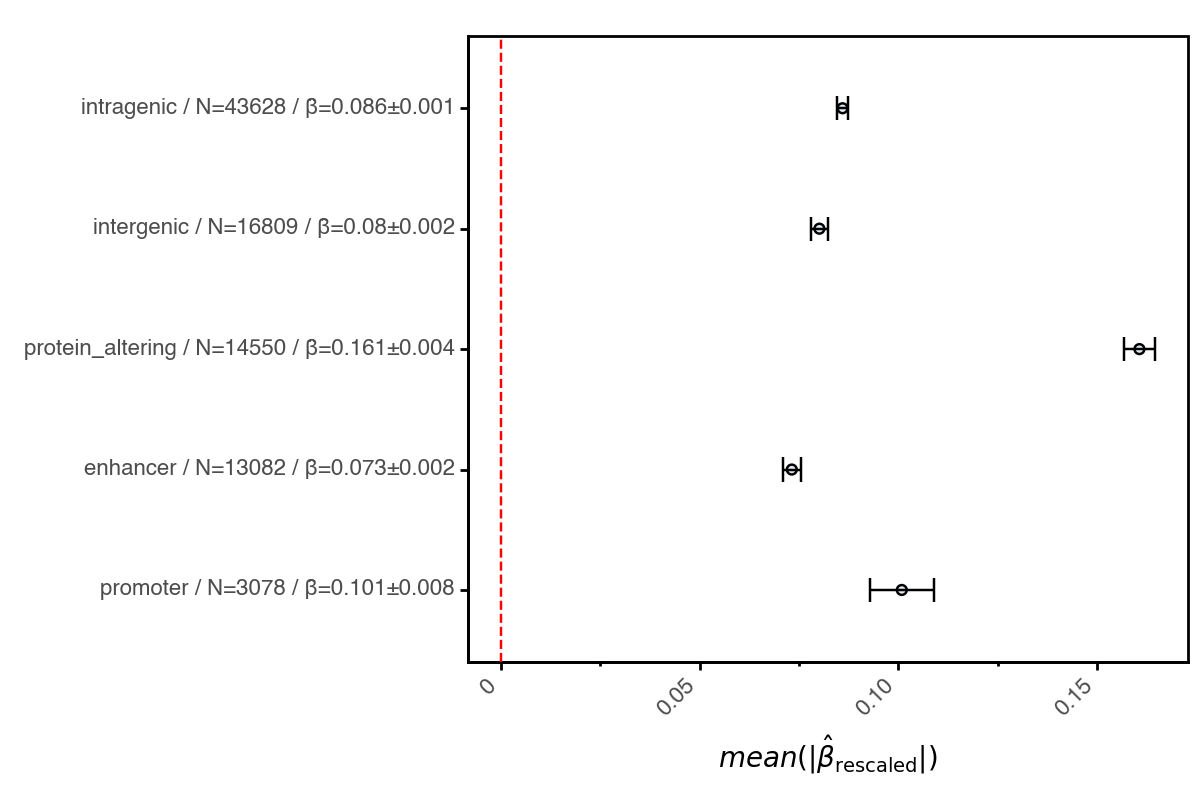

<Figure Size: (600 x 400)>

In [ ]:
plot = (
    p9.ggplot(data_measurement)
    + p9.geom_point(p9.aes(x="reorder(label, variantCount)", y="meanAbsEstimatedBeta"), fill="#DBEAF6")
    + OpenTargetsTheme.theme
    + p9.theme(figure_size=(10, 6))
    # move the y-axis label to the bottom
    + p9.theme(axis_text_y=p9.element_text(rotation=0))
    + p9.geom_errorbar(
        p9.aes(
            x="label",
            ymin="meanAbsEstimatedBeta - intervalAbsEstimatedBeta",
            ymax="meanAbsEstimatedBeta + intervalAbsEstimatedBeta",
        ),
        width=0.2,
        position=p9.position_dodge(width=0.9),
    )
    + p9.labs(x="", y=r"$mean(|\hat{\beta}_{\mathrm{rescaled}}|)$")
    + p9.theme(legend_position="left", figure_size=(6, 4))  # Remove the legend
    # Remove the color scale from legend
    + p9.geom_hline(p9.aes(yintercept=0), linetype="dashed", color="red", size=0.5)
    + p9.coord_flip()
)
plot


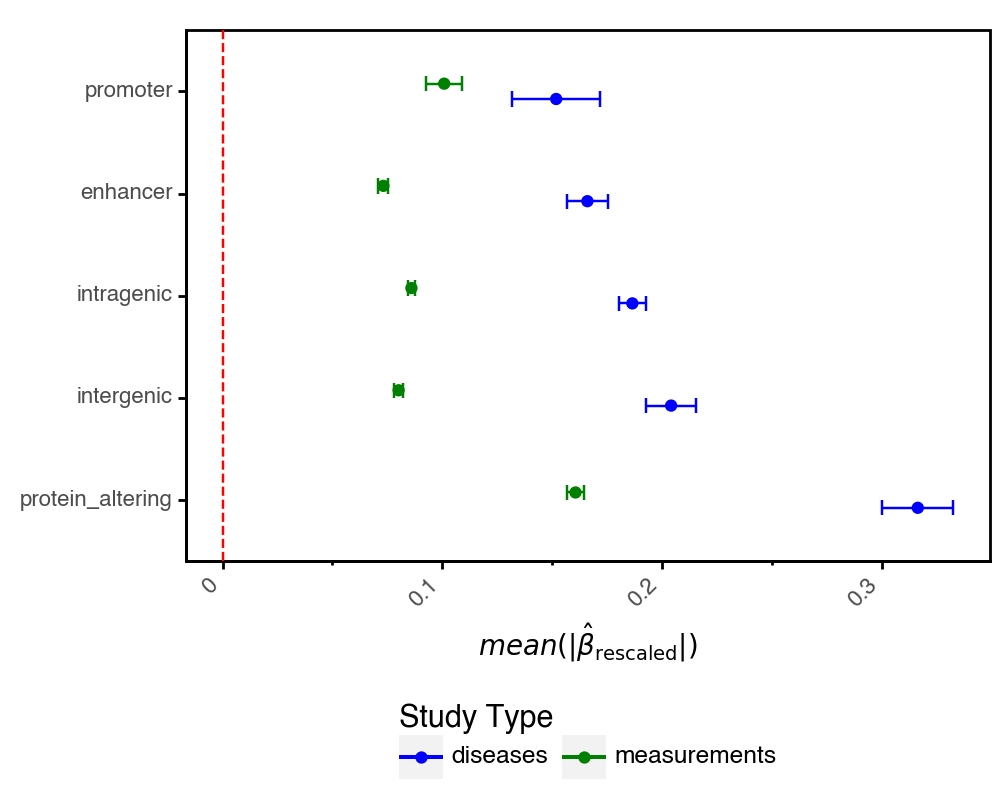

<Figure Size: (500 x 400)>

In [ ]:
# Combine both datasets for plotting
data_diseases_labeled = data_diseases.copy()
data_diseases_labeled["study_category"] = "diseases"

data_measurement_labeled = data_measurement.copy()
data_measurement_labeled["study_category"] = "measurements"

# Combine the datasets
combined_data = pd.concat([data_diseases_labeled, data_measurement_labeled], ignore_index=True)

# Create ordering based on measurements meanAbsEstimatedBeta (highest to lowest)
measurement_order = data_diseases_labeled.sort_values("meanAbsEstimatedBeta", ascending=False)["consequence"].tolist()

# Convert consequence to categorical with custom order
combined_data["consequence"] = pd.Categorical(combined_data["consequence"], categories=measurement_order, ordered=True)

# Create combined plot
combined_plot = (
    p9.ggplot(combined_data)
    + p9.geom_point(
        p9.aes(x="consequence", y="meanAbsEstimatedBeta", color="study_category"),
        size=1.5,
        position=p9.position_dodge(width=0.3),
    )
    + p9.geom_errorbar(
        p9.aes(
            x="consequence",
            ymin="meanAbsEstimatedBeta - intervalAbsEstimatedBeta",
            ymax="meanAbsEstimatedBeta + intervalAbsEstimatedBeta",
            color="study_category",
        ),
        width=0.3,
        position=p9.position_dodge(width=0.3),
    )
    + p9.scale_color_manual(values={"measurements": "green", "diseases": "blue"}, name="Study Type")
    + OpenTargetsTheme.theme
    + p9.theme(axis_text_y=p9.element_text(rotation=0))
    + p9.labs(x="", y=r"$mean(|\hat{\beta}_{\mathrm{rescaled}}|)$")
    + p9.theme(legend_position="bottom", figure_size=(5, 4))
    + p9.geom_hline(p9.aes(yintercept=0), linetype="dashed", color="red", size=0.5)
    + p9.coord_flip()
)
combined_plot


## Mean estimated effect size in consequence categories x study Type

This analysis is done to see the difference between the mean estimated effect size in different consequence categories across the study types.


In [ ]:
data2 = (
    merged_dataset.withColumn(
        "totalCountPerStudyType", f.count(f.col("variantId")).over(Window.partitionBy("studyType"))
    )
    .withColumn(
        "totalCountPerStudyTypeAndConsequence",
        f.count(f.col("variantId")).over(Window.partitionBy("studyType", "consequence")),
    )
    .withColumn("totalCountPerConsequence", f.count(f.col("variantId")).over(Window.partitionBy("consequence")))
    .withColumn("percentage", f.col("totalCountPerStudyTypeAndConsequence") / f.col("totalCountPerStudyType"))
    .drop_duplicates(["consequence", "studyType", "totalCountPerStudyTypeAndConsequence", "totalCountPerStudyType"])
    .withColumn(
        "cumulativeSum",
        f.sum(f.col("percentage")).over(Window.partitionBy("studyType").orderBy(f.desc("totalCountPerConsequence"))),
    )
    .withColumn("pointLabel", f.concat_ws("", f.format_number(f.col("percentage") * 100, 2), f.lit("%")))
    .withColumn("pointLabelPosition", f.col("cumulativeSum") - (f.col("percentage") / 2))
    .withColumn("fillLabel", f.col("consequence"))
    .select(
        "pointLabel",
        "pointLabelPosition",
        "fillLabel",
        "percentage",
        "consequence",
        "studyType",
        "totalCountPerStudyTypeAndConsequence",
        "totalCountPerStudyType",
        "totalCountPerConsequence",
        "cumulativeSum",
    )
    .orderBy("totalCountPerStudyTypeAndConsequence", ascending=False)
    .toPandas()
)
data2.sort_values(by=["studyType", "totalCountPerConsequence"], ascending=[True, False], inplace=True)
data2["label_to_show"] = data2.apply(lambda row: f"{row['pointLabel']}" if row["percentage"] > 0.05 else "", axis=1)
data2


,pointLabel,pointLabelPosition,fillLabel,percentage,consequence,studyType,totalCountPerStudyTypeAndConsequence,totalCountPerStudyType,totalCountPerConsequence,cumulativeSum,label_to_show
14,41.89%,0.209450,intragenic,0.418901,intragenic,cis-pqtl,625,1492,250448,0.418901,41.89%
17,17.16%,0.504692,enhancer,0.171582,enhancer,cis-pqtl,256,1492,69977,0.590483,17.16%
19,10.86%,0.644772,intergenic,0.108579,intergenic,cis-pqtl,162,1492,63833,0.699062,10.86%
18,11.80%,0.758043,promoter,0.117962,promoter,cis-pqtl,176,1492,44543,0.817024,11.80%
16,18.30%,0.908512,protein_altering,0.182976,protein_altering,cis-pqtl,273,1492,30715,1.000000,18.30%
0,56.50%,0.282478,intragenic,0.564957,intragenic,eqtl,200098,354183,250448,0.564957,56.50%
1,15.42%,0.642071,enhancer,0.154228,enhancer,eqtl,54625,354183,69977,0.719185,15.42%
2,12.62%,0.782262,intergenic,0.126155,intergenic,eqtl,44682,354183,63833,0.845340,12.62%
4,11.57%,0.903176,promoter,0.115672,promoter,eqtl,40969,354183,44543,0.961012,11.57%
7,3.90%,0.980506,protein_altering,0.038988,protein_altering,eqtl,13809,354183,30715,1.000000,


C


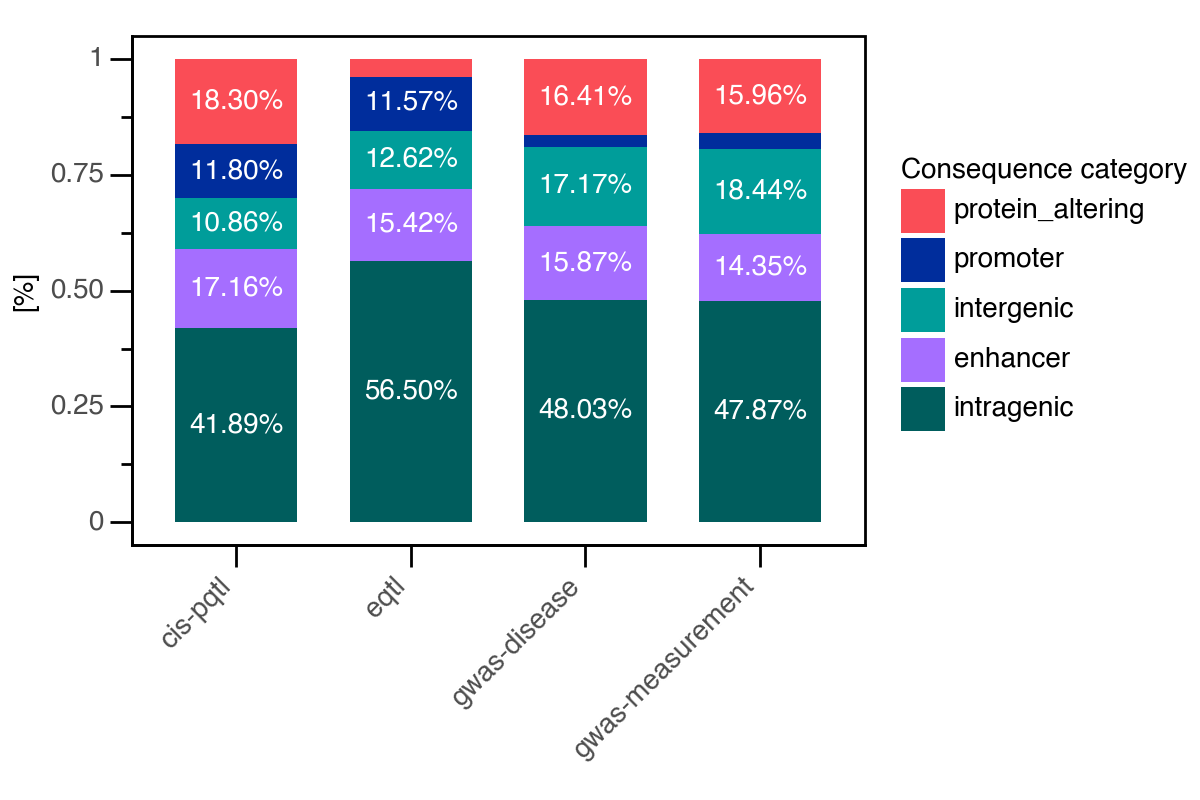

<Figure Size: (600 x 400)>

In [ ]:
plot2 = (
    p9.ggplot(data2)
    + p9.geom_col(p9.aes(x="studyType", y="percentage", fill="reorder(fillLabel, totalCountPerConsequence)"), width=0.7)
    + OpenTargetsTheme.categorical_theme(5)
    + p9.theme(figure_size=(6, 4))
    + p9.theme(
        axis_text_y=p9.element_text(rotation=0, hjust=1, size=10),
        axis_text_x=p9.element_text(size=10),
        legend_text=p9.element_text(size=10),
    )
    + p9.labs(x="", y="[%]", fill="Consequence category")
    + p9.theme(legend_title=p9.element_text(size=10, weight=50), legend_position="right")
    # Move the geom_text to point to the correct part of the bar
    # + p9.geom_text(p9.aes(label="%", y="percentage", x="studyType"), size=8, color="black")
    + p9.geom_text(p9.aes(label="label_to_show", y="pointLabelPosition", x="studyType"), size=10, color="white")
    + p9.scale_fill_manual(values=OpenTargetsTheme.categorical_dark_colors)
)
plot2


In [ ]:
merged_dataset.show(1)


+----------------+------------+-------------------+------------------+---------+------------------------+--------------------+-----------+
|       variantId|intervalType|      estimatedBeta|       estimatedSE|studyType|consequenceOntologyTerms|                 MAF|consequence|
+----------------+------------+-------------------+------------------+---------+------------------------+--------------------+-----------+
|10_100251945_G_A|        NULL|-1.4057668943206896|0.2947352895027342|     eqtl|        [intron_variant]|0.046809761834754486| intragenic|
+----------------+------------+-------------------+------------------+---------+------------------------+--------------------+-----------+
only showing top 1 row



In [ ]:
data3 = (
    merged_dataset.filter(f.col("consequence").isin(["promoter", "enhancer"]))
    .withColumn("totalCountPerStudyType", f.count(f.col("variantId")).over(Window.partitionBy("studyType")))
    .withColumn(
        "totalCountPerStudyTypeAndConsequence",
        f.count(f.col("variantId")).over(Window.partitionBy("studyType", "consequence")),
    )
    .withColumn("totalCountPerConsequence", f.count(f.col("variantId")).over(Window.partitionBy("consequence")))
    .withColumn("percentage", f.col("totalCountPerStudyTypeAndConsequence") / f.col("totalCountPerStudyType"))
    .drop_duplicates(["consequence", "studyType", "totalCountPerStudyTypeAndConsequence", "totalCountPerStudyType"])
    .withColumn(
        "cumulativeSum",
        f.sum(f.col("percentage")).over(Window.partitionBy("studyType").orderBy(f.desc("totalCountPerConsequence"))),
    )
    .withColumn("pointLabel", f.concat_ws("", f.format_number(f.col("percentage") * 100, 2), f.lit("%")))
    .withColumn("pointLabelPosition", f.col("cumulativeSum") - (f.col("percentage") / 2))
    .withColumn("fillLabel", f.concat_ws(" / ", "consequence", "totalCountPerConsequence"))
    .select(
        "pointLabel",
        "pointLabelPosition",
        "fillLabel",
        "percentage",
        "consequence",
        "studyType",
        "totalCountPerStudyTypeAndConsequence",
        "totalCountPerStudyType",
        "totalCountPerConsequence",
        "cumulativeSum",
    )
    .orderBy("totalCountPerStudyTypeAndConsequence", ascending=False)
    .toPandas()
)
data3.sort_values(by=["studyType", "totalCountPerConsequence"], ascending=[True, False], inplace=True)
data3["label_to_show"] = data3.apply(lambda row: f"{row['pointLabel']}" if row["percentage"] > 0.05 else "", axis=1)
data3


,pointLabel,pointLabelPosition,fillLabel,percentage,consequence,studyType,totalCountPerStudyTypeAndConsequence,totalCountPerStudyType,totalCountPerConsequence,cumulativeSum,label_to_show
5,61.39%,0.306950,enhancer / 29370,0.613900,enhancer,cis-pqtl,318,518,29370,0.613900,61.39%
6,38.61%,0.806950,promoter / 9941,0.386100,promoter,cis-pqtl,200,518,9941,1.000000,38.61%
0,73.50%,0.367503,enhancer / 29370,0.735006,enhancer,eqtl,24339,33114,29370,0.735006,73.50%
1,26.50%,0.867503,promoter / 9941,0.264994,promoter,eqtl,8775,33114,9941,1.000000,26.50%
3,83.09%,0.415452,enhancer / 29370,0.830904,enhancer,gwas-disease,855,1029,29370,0.830904,83.09%
7,16.91%,0.915452,promoter / 9941,0.169096,promoter,gwas-disease,174,1029,9941,1.000000,16.91%
2,82.97%,0.414839,enhancer / 29370,0.829677,enhancer,gwas-measurement,3858,4650,29370,0.829677,82.97%
4,17.03%,0.914839,promoter / 9941,0.170323,promoter,gwas-measurement,792,4650,9941,1.000000,17.03%


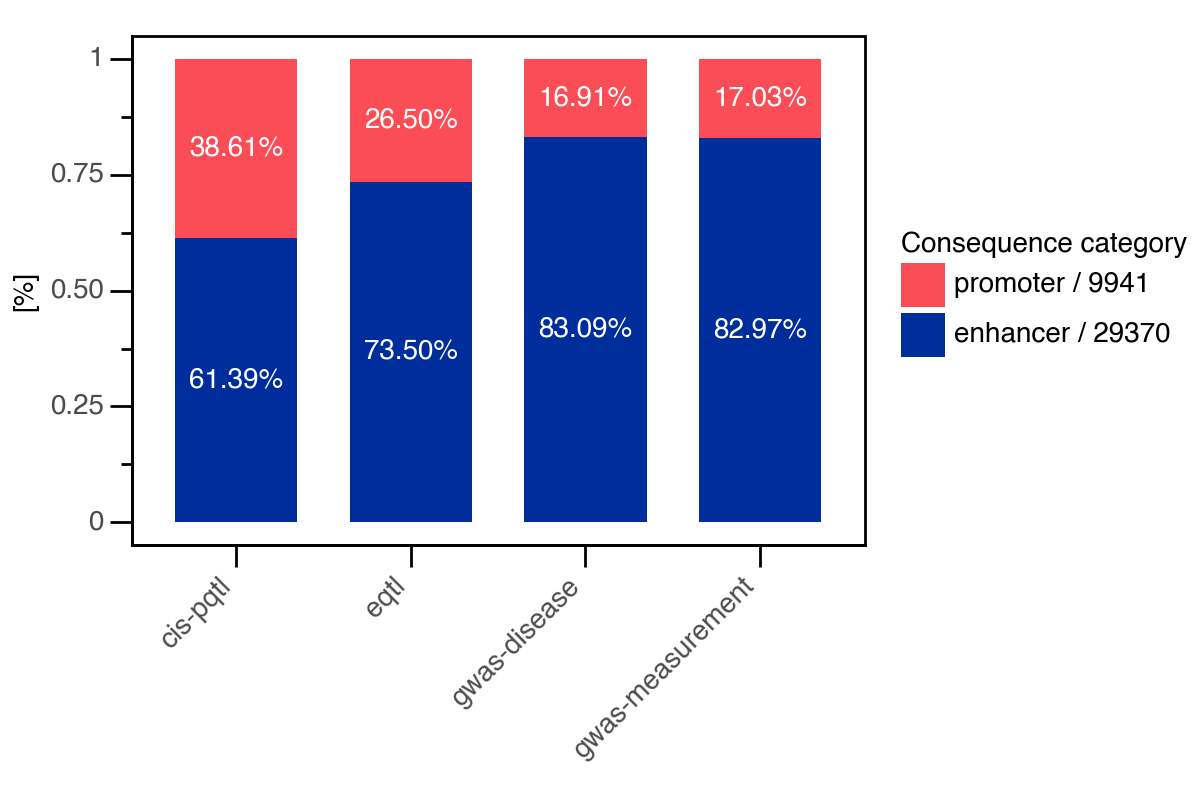

<Figure Size: (600 x 400)>

In [ ]:
plot3 = (
    p9.ggplot(data3)
    + p9.geom_col(p9.aes(x="studyType", y="percentage", fill="reorder(fillLabel, totalCountPerConsequence)"), width=0.7)
    + OpenTargetsTheme.categorical_theme(5)
    + p9.theme(figure_size=(6, 4))
    + p9.theme(
        axis_text_y=p9.element_text(rotation=0, hjust=1, size=10),
        axis_text_x=p9.element_text(size=10),
        legend_text=p9.element_text(size=10),
    )
    + p9.labs(x="", y="[%]", fill="Consequence category")
    + p9.theme(legend_title=p9.element_text(size=10, weight=50), legend_position="right")
    # Move the geom_text to point to the correct part of the bar
    # + p9.geom_text(p9.aes(label="%", y="percentage", x="studyType"), size=8, color="black")
    + p9.geom_text(p9.aes(label="label_to_show", y="pointLabelPosition", x="studyType"), size=10, color="white")
    + p9.scale_fill_manual(values=OpenTargetsTheme.categorical_dark_colors)
)
plot3


# molQTLs


In [ ]:
data_diseases_all = (
    gwas_dataset.withColumn("absEstimatedBeta", f.abs(f.col("estimatedBeta")))
    .withColumn("diseaseIds_ws", f.concat_ws(",", f.col("diseaseIds")))
    .drop("diseaseIds")
    .toPandas()
)
data_diseases_all.iloc[0:2, :]


,variantId,intervalType,estimatedBeta,estimatedSE,studyType,consequenceOntologyTerms,MAF,studyLocusId,geneId,biosampleId,consequence,absEstimatedBeta,diseaseIds_ws
0,6_49393839_G_A,None,-0.043239,0.008639,gwas-disease,"[intron_variant, non_coding_transcript_variant]",0.370756,00267e1e5f63200beaac6cd04a638d7f,None,None,intragenic,0.043239,EFO_0000712
1,8_9227785_A_T,None,-0.067426,0.010879,gwas-disease,"[intron_variant, non_coding_transcript_variant]",0.489803,02c553c6d12a7cfac86d031d8863e604,None,None,intragenic,0.067426,MONDO_0005178


In [ ]:
data_diseases_all.to_csv("../../data/data_diseases_all.csv", index=False)


In [ ]:
data_measurement_all = (
    gwas_measurement.withColumn("absEstimatedBeta", f.abs(f.col("estimatedBeta")))
    .withColumn("diseaseIds_ws", f.concat_ws(",", f.col("diseaseIds")))
    .drop("diseaseIds")
    .toPandas()
)
data_measurement_all.iloc[0:2, :]


,variantId,intervalType,estimatedBeta,estimatedSE,studyType,consequenceOntologyTerms,MAF,studyLocusId,geneId,biosampleId,consequence,absEstimatedBeta,diseaseIds_ws
0,16_85663029_A_T,None,-0.080801,0.013516,gwas-measurement,[missense_variant],0.006752,0012a68bde67dd6e96e8fa6ffae8c40b,None,None,protein_altering,0.080801,EFO_0007984
1,12_10444121_T_C,None,-0.035354,0.003033,gwas-measurement,[upstream_gene_variant],0.158253,00709081d40ee78dacd63cbdae6c6318,None,None,intergenic,0.035354,OBA_0003460


In [ ]:
data_measurement_all.to_csv("../../data/data_measurement_all.csv", index=False)


25/08/16 02:13:48 WARN HeartbeatReceiver: Removing executor driver with no recent heartbeats: 953887 ms exceeds timeout 120000 ms
25/08/16 02:13:48 WARN SparkContext: Killing executors is not supported by current scheduler.
25/08/16 02:30:31 ERROR Inbox: Ignoring error
org.apache.spark.SparkException: Exception thrown in awaitResult: 
	at org.apache.spark.util.SparkThreadUtils$.awaitResult(SparkThreadUtils.scala:56)
	at org.apache.spark.util.ThreadUtils$.awaitResult(ThreadUtils.scala:310)
	at org.apache.spark.rpc.RpcTimeout.awaitResult(RpcTimeout.scala:75)
	at org.apache.spark.rpc.RpcEnv.setupEndpointRefByURI(RpcEnv.scala:102)
	at org.apache.spark.rpc.RpcEnv.setupEndpointRef(RpcEnv.scala:110)
	at org.apache.spark.util.RpcUtils$.makeDriverRef(RpcUtils.scala:36)
	at org.apache.spark.storage.BlockManagerMasterEndpoint.driverEndpoint$lzycompute(BlockManagerMasterEndpoint.scala:124)
	at org.apache.spark.storage.BlockManagerMasterEndpoint.org$apache$spark$storage$BlockManagerMasterEndpoint$$

In [ ]:
beta = "\u03b2"
hat = "\u0302"
plus_minus = "\u00b1"


data_eqtl = (
    molQTLs_dataset.filter(f.col("studyType") == "eqtl")
    .groupBy("consequence", "studyType")
    .agg(
        f.mean(f.abs("estimatedBeta")).alias("meanAbsEstimatedBeta"),
        f.stddev(f.abs("estimatedBeta")).alias("stddevAbsEstimatedBeta"),
        (f.lit(1.96) * f.stddev(f.abs("estimatedBeta")) / f.sqrt(f.count(f.abs("estimatedBeta")))).alias(
            "intervalAbsEstimatedBeta"
        ),
        f.count(f.col("variantId")).alias("variantCount"),
    )
    .withColumn(
        "label",
        f.concat_ws(
            " / ",
            "consequence",
            f.concat_ws("=", f.lit("N"), "variantCount"),
            f.concat_ws(
                plus_minus,
                f.concat_ws("=", f.lit(beta + hat), f.round("meanAbsEstimatedBeta", 3)),
                f.round("intervalAbsEstimatedBeta", 3),
            ),
        ),
    )
    .toPandas()
)
data_eqtl
